In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sklearn
from sklearn.datasets import make_circles

# 02. Neural Network classification with PyTorch

classification is a problem of predicting wheather something is one thing or another (there are other types of things)

## 1. Make classification data and get it ready

In [2]:
# Make 1000 samples

n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of Y {y[:5]}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of Y [1 1 1 1 0]


In [5]:
X.shape

(1000, 2)

In [6]:
# Make a DataFrame of circle data
circles = pd.DataFrame({"X1": X[:, 0], 
                        "X2": X[:, 1],
                       "label" : y})

In [7]:
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


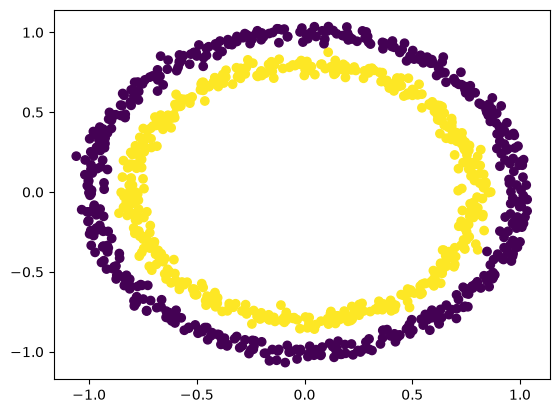

In [8]:
# Visualize, visualize, visualize
plt.scatter(x = X[:, 0],
            y = X[:, 1],
            c = y)

Note: The data we're working with is often reffered to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundementals

## 1.1 Check input and output shapes

In [9]:
X.shape, y.shape

((1000, 2), (1000,))

In [10]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [11]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"VAlues for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

VAlues for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### 1.2 Turn data into tensors and create train and test splits

In [12]:
import torch
torch.__version__

'2.13.0+cu126'

In [13]:
X.dtype

dtype('float64')

In [14]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [15]:
X.dtype

torch.float32

In [16]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [17]:
# Splitn data into training and test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42)


In [18]:
X_train.shape, X_test.shape

(torch.Size([800, 2]), torch.Size([200, 2]))

## 2. Building a model

Let's build a model to classify our blue and red dots.

To do so, we want to:
1. Setup device agnostic code so our code will run on an accelerator (GPU) if there is one.
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss function and optimizer 
4. Create a training and test loop

In [19]:
torch.cuda.is_available()

True

In [20]:
# import PYTorch and nn
import torch
import torch.nn as nn

#  Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "CPU"
device

'cuda'

In [21]:
import sys
print(sys.executable)

c:\Users\hassa\Documents\Practice\Pytorch\.venv\Scripts\python.exe


In [22]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.13.0+cu126
True
12.6


In [23]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we've setup device agnostic code, let's create a model that:

1. SUbclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`)
2. Create 2 `nn.Linear` layers that are capable of handing the shapes of our data
3. Defines a `forward()`method that outlines the forward pass (or forward computation) of our model
4. Instattiate an instance of our model class and send it to the target device

In [24]:
y_train[:5]

tensor([1., 0., 0., 0., 1.])

In [25]:
# 1. Construct a model that subclasses nn.Module

class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handing the shapes of our data
        self.layer_1 = nn.Linear(in_features=2, out_features=8) # Takes in 2 features and upscales to 5 features
        self.layer_2 = nn.Linear(in_features=8, out_features=1) # Takes in 5 features from previous layer and output a single feature (same shape as y)

        # 3. Define a forward() method that outlines the forward pass
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_2(self.layer_1(x)) # x-> layer 1 -> layer 2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=8, bias=True)
  (layer_2): Linear(in_features=8, out_features=1, bias=True)
)

In [26]:
device

'cuda'

In [27]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [28]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.5244,  0.0286],
                      [-0.1066,  0.2897],
                      [ 0.4828, -0.6642],
                      [ 0.0312, -0.4213],
                      [-0.3769, -0.1236],
                      [-0.2861, -0.0461],
                      [-0.0672,  0.6415],
                      [ 0.6308, -0.2607]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.0217,  0.2726, -0.3030, -0.4247, -0.3163,  0.3078, -0.0412, -0.5286],
                     device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.1996, -0.0541,  0.1526,  0.2884,  0.2174,  0.2358,  0.1255,  0.2728]],
                     device='cuda:0')),
             ('layer_2.bias', tensor([0.3094], device='cuda:0'))])

In [29]:
# Let's replicate the model above using nn.Sequential(). This is also an option if your model

model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=8),
    nn.Linear(in_features=8, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): Linear(in_features=8, out_features=1, bias=True)
)

In [30]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5539,  0.0756],
                      [-0.5153,  0.5378],
                      [ 0.6079,  0.6112],
                      [-0.6258,  0.5385],
                      [ 0.0162, -0.4427],
                      [-0.6666,  0.0327],
                      [-0.0633,  0.5981],
                      [ 0.2500, -0.0056]], device='cuda:0')),
             ('0.bias',
              tensor([-0.3525, -0.4857,  0.5943, -0.5692, -0.6991,  0.5592, -0.6756,  0.3413],
                     device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0836,  0.0781, -0.0976, -0.1007, -0.1027, -0.2975,  0.2635, -0.0122]],
                     device='cuda:0')),
             ('1.bias', tensor([-0.0764], device='cuda:0'))])

In [31]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
    print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
    print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
    print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
    print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.4040],
        [-0.2956],
        [-0.5927],
        [-0.3509],
        [-0.4413],
        [-0.3763],
        [-0.1911],
        [-0.2096],
        [-0.5988],
        [-0.2867]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [32]:
y_test, X_test

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0.,
         1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1.,
         1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
         1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
         0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0.,
         1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0.,
         0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0.,
         1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1.,
         0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1.,
         1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
         0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0.,
         1., 1.]),
 tensor([[-3.7519e-01,  6.8266e-01],
         [ 1.5380e-02,  9.6003e-01],
         [-7.027

### 2.1 Setup loss function and optimizer

Which loss function or optimizer should you use?

Again... this is problem specific

For example for regression you might waant MAE or MSE (mean absolute error or mean squared error)

For classification you might want binary cross entrophy or categorical cross entropy (cross entropy)

As a reminder, the loss function measure how wrong your model is.

And for optimizers, two of the most common and useful are SGD and Adam but PyTorch has a lots of them

* For the loss function we are going to use `torch.nn.BECWwithLogitsLoss()` for more on what binary cross entropy (BCE) is, check out the article by towardsfdatascience

* For a definition on what a logit is in deep learning

* For different optimizers are `torch.optim`

In [33]:
# Setup the loss function
# loss_fn = nn.BCELoss() # BCELoss # requires inputs to have gone through the sigmoid ativation function prior to input to BCELoss
# nn.Sequential(
#     nn.Sigmoid(),
#     nn.BCELoss()
# )

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.09)

In [34]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5539,  0.0756],
                      [-0.5153,  0.5378],
                      [ 0.6079,  0.6112],
                      [-0.6258,  0.5385],
                      [ 0.0162, -0.4427],
                      [-0.6666,  0.0327],
                      [-0.0633,  0.5981],
                      [ 0.2500, -0.0056]], device='cuda:0')),
             ('0.bias',
              tensor([-0.3525, -0.4857,  0.5943, -0.5692, -0.6991,  0.5592, -0.6756,  0.3413],
                     device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0836,  0.0781, -0.0976, -0.1007, -0.1027, -0.2975,  0.2635, -0.0122]],
                     device='cuda:0')),
             ('1.bias', tensor([-0.0764], device='cuda:0'))])

In [35]:
# Calculate the accuracy  - out of 100 examples, what percetntage does our model get right?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

### 3. Train model

To train our model, we are going to follow the steps:

1. Forward pass 
2. Calculate the loss
3. Optiizer zero grad
4. Loss backward (backpropgation)
5. Optimizer step (gradient descent)
6. Making the prediction using `torch.inference_mode()`

* Train the model
* Make the predictions

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Out model outputs are going to be raw *logits*

We can convert these **logits** into **prediction** probabilities by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multi class classification)

Then we can convert out model's prediction probabilities to prediction labels by either rounding them or taking the `argmax()`

In [36]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5] # Logits are the raw outputs of our model without being passed to an activation function

In [37]:
y_logits

tensor([[-0.4040],
        [-0.2956],
        [-0.5927],
        [-0.3509],
        [-0.4413]], device='cuda:0')

For our prediction probability values, we need to perform a range-stryle rounding on them:

* `y_pred_probs` >= 0.5, `y=` (class 1)
* `y_pred_probs` < 0.5, `y=0` (class 0)

In [38]:
# Use the sigmoid activation model on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4004],
        [0.4266],
        [0.3560],
        [0.4132],
        [0.3914]], device='cuda:0')

In [39]:
y_preds = torch.round(y_pred_probs)
print(f"This is y_preds {y_preds}")
print(f"This is y_preds shape {y_preds.shape}")

# In full (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))
print(f"This is y_preds_labels {y_pred_labels}")
print(f"This is y_preds_labels shape {y_pred_labels.shape}")

# Check for equality 
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

This is y_preds tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')
This is y_preds shape torch.Size([5, 1])
This is y_preds_labels tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0', grad_fn=<RoundBackward0>)
This is y_preds_labels shape torch.Size([5, 1])
tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [40]:
device

'cuda'

In [41]:
print(X_train.device)
print(y_train.device)
print(X_test.device)
print(y_test.device)

cpu
cpu
cpu
cpu


### 3.2 Building a training and testing loop

In [42]:
torch.manual_seed(42)

epochs = 1000
model_1 = CircleModelV0().to(device)
optimizer_mod1 = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.01)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    
    model_1.train()

    # Making prediction (getting the r|aw logit numbers)
    y_preds = model_1(X_train)
    y_preds = y_preds.squeeze()

    # 1. Forward Pass

    # Apply the sigmoid
    logit_prob_pred = torch.sigmoid(y_preds)
    logit_prob_pred = torch.round(logit_prob_pred)

    # 2. Loss/accuracy
    loss_model = loss_fn(y_preds,  # expects raw logits as input
                         y_train)
    
    acc = accuracy_fn(y_true = y_train,
                      y_pred = logit_prob_pred)

    # 3. Optimizer 0 grad to make the gradients back to 0
    optimizer_mod1.zero_grad()

    #4. Loss backwards
    loss_model.backward()

    # 5. Optimizer step (updates the parameters)
    optimizer_mod1.step()

    # Testing
    model_1.eval()

    with torch.inference_mode():
        test_preds_logits = model_1(X_test)
        test_preds_logits = test_preds_logits.squeeze()
        test_preds_logits = torch.sigmoid(test_preds_logits)
        test_preds = torch.round(test_preds_logits)

        # Calculate test loss/acc
        loss_preds_model = loss_fn(test_preds_logits, 
                                   y_test)
        
        test_acc = accuracy_fn(y_true = y_test,
                               y_pred = test_preds)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss_model: {loss_model}, test_loss_model {loss_preds_model}, accuracy {test_acc}")

    



Epoch: 0, loss_model: 0.7054367661476135, test_loss_model 0.7181929349899292, accuracy 53.0
Epoch: 10, loss_model: 0.7048197984695435, test_loss_model 0.7184576392173767, accuracy 53.5
Epoch: 20, loss_model: 0.704250156879425, test_loss_model 0.7187092304229736, accuracy 54.0
Epoch: 30, loss_model: 0.7037228941917419, test_loss_model 0.7189483642578125, accuracy 53.5
Epoch: 40, loss_model: 0.7032339572906494, test_loss_model 0.7191756963729858, accuracy 53.0
Epoch: 50, loss_model: 0.7027795314788818, test_loss_model 0.7193917632102966, accuracy 53.0
Epoch: 60, loss_model: 0.7023563981056213, test_loss_model 0.7195971608161926, accuracy 53.0
Epoch: 70, loss_model: 0.7019615173339844, test_loss_model 0.7197923064231873, accuracy 52.0
Epoch: 80, loss_model: 0.7015923857688904, test_loss_model 0.719977855682373, accuracy 52.5
Epoch: 90, loss_model: 0.7012465000152588, test_loss_model 0.720154345035553, accuracy 52.5
Epoch: 100, loss_model: 0.7009217739105225, test_loss_model 0.720322012901

In [43]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

## 4. Make predictions and evaluate the model

From the metrics it looks like our model is jot learning anything. So to inspect it let's make some predictions and make them visual:

In other words "Visualize, Visualiz and Visualize"

To do so, we are going to import a function called `plot_decision_boundary()`

In [44]:
import requests
from pathlib import Path

# Download helper function from Leaarn PyTorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_function.py already exists, skipping download")
else:
    print("It doesn't exist, downloading it now")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

helper_function.py already exists, skipping download


In [45]:
from helper_functions import plot_predictions, plot_decision_boundary

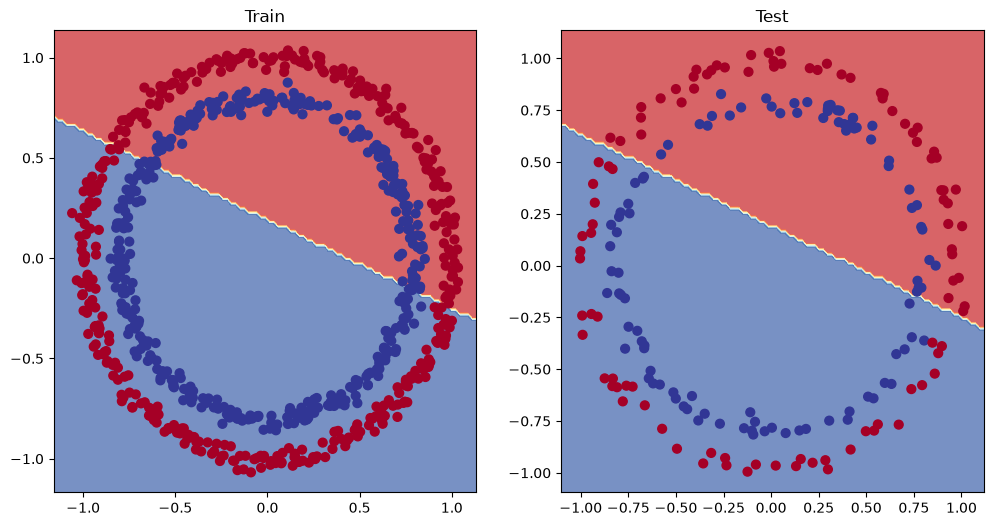

In [46]:
plt.figure(figsize = (12,6 ))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)


## 5. Improving a model (from a model perspective)

* Add more layers - give the model more chances to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units
* Changing the activation functions
* Change the learning rate

These options are all from a model's perspective because they deal directly with the model, rather than the data

and because these options are all values we (as machine learning enginers and ata scientists) can change, they are referred as ***hyperparameters***

Let's try and improve our model by:

* Adding more hidden units: 5 -> 10
* Increase the number of layers: 2->3
* Increase the number of epochs: 100 -> 1000

In [47]:
X_train[:5]

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]], device='cuda:0')

In [48]:
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10,out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10,out_features = 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x))) # this way of writing operations leverages speeds up where possible behind the scenes

model_2 = CircleModelV2().to(device)
model_2
           

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [49]:
X_train.shape

torch.Size([800, 2])

In [50]:
# loss_fn = nn.BCEWithLogitsLoss()
# optimizer = torch.optim.SGD(params = model_0.parameters(),
#                             lr = 0.09)

In [51]:
# Create a loss function
loss_model2 = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer_model2 = torch.optim.SGD(params = model_2.parameters(),
                                   lr = 0.01)

In [52]:
device

'cuda'

In [53]:
model_2

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [54]:
# Write an avaluation 
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000
 
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # Training
    model_2.train()

    # 1. Forward pass
    logit_pred = model_2(X_train).squeeze() # raw logit output
    y_pred = torch.round(torch.sigmoid(logit_pred)) # Logits -> pred probabilities -> prediction

    # 2. Calculate the loss/acc
    loss = loss_model2(logit_pred, y_train)
    acc = accuracy_fn(y_true = y_train,
                      y_pred = y_pred)
    
    # 3. Optimizer zero grad
    optimizer_model2.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Step
    optimizer_model2.step()

    # 6. Model eval
    model_2.eval()

    with torch.inference_mode():
        # 1. Forward pass

        test_logits = model_2(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate the loss
        test_loss = loss_model2(test_logits,
                                y_test)
        
        test_acc = accuracy_fn(y_true = y_test,
                               y_pred = test_pred)
        
    
        # Print out what's happening
        if epoch % 100 == 0:
            print(f"Epoch: {epoch} | Loss: {loss: 5f}, Acc: {acc:2f} | Test loss: {test_loss:5f}, Test acc: {test_acc}")
    

Epoch: 0 | Loss:  0.694235, Acc: 56.875000 | Test loss: 0.696479, Test acc: 54.0
Epoch: 100 | Loss:  0.693559, Acc: 53.125000 | Test loss: 0.695539, Test acc: 48.5
Epoch: 200 | Loss:  0.693314, Acc: 52.250000 | Test loss: 0.695137, Test acc: 47.5
Epoch: 300 | Loss:  0.693218, Acc: 51.250000 | Test loss: 0.694946, Test acc: 48.0
Epoch: 400 | Loss:  0.693174, Acc: 51.250000 | Test loss: 0.694843, Test acc: 48.0
Epoch: 500 | Loss:  0.693150, Acc: 50.750000 | Test loss: 0.694781, Test acc: 48.0
Epoch: 600 | Loss:  0.693134, Acc: 50.250000 | Test loss: 0.694740, Test acc: 49.0
Epoch: 700 | Loss:  0.693120, Acc: 50.000000 | Test loss: 0.694711, Test acc: 49.0
Epoch: 800 | Loss:  0.693109, Acc: 50.250000 | Test loss: 0.694689, Test acc: 48.5
Epoch: 900 | Loss:  0.693099, Acc: 50.625000 | Test loss: 0.694672, Test acc: 48.5


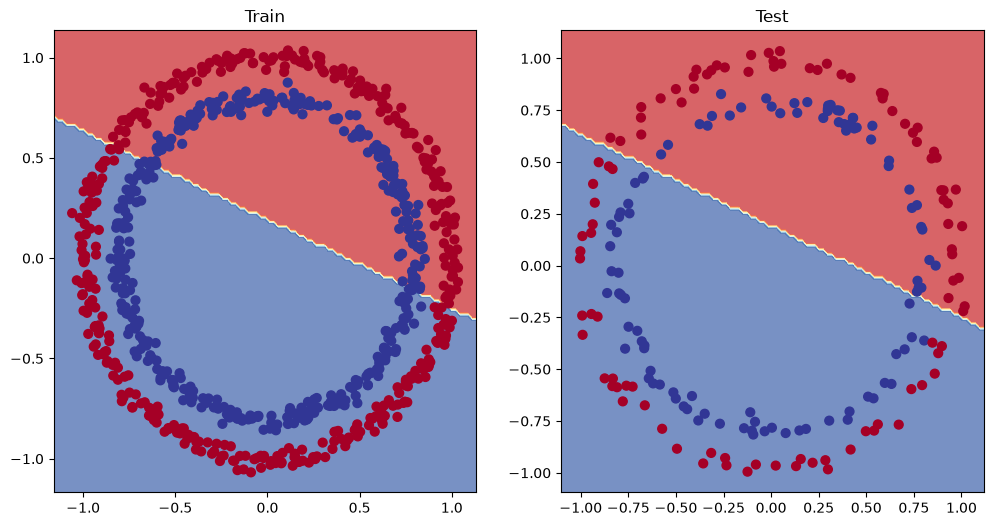

In [55]:
# Plot the decision boundary

plt.figure(figsize = (12,6 ))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, 
                        y_test)

### 5.1 Preparing data to see if our model can fit a straight line

One wau to trouble shoot a larger problem is to troubleshoot a smaller problem

In [56]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step  = 0.01

# create data
X_regression = torch.arange(start, end, step).unsqueeze(dim = 1)
y_regression = weight * X_regression + bias

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [57]:
# Create train and test split
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the length of each
len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)

(80, 20, 80, 20)

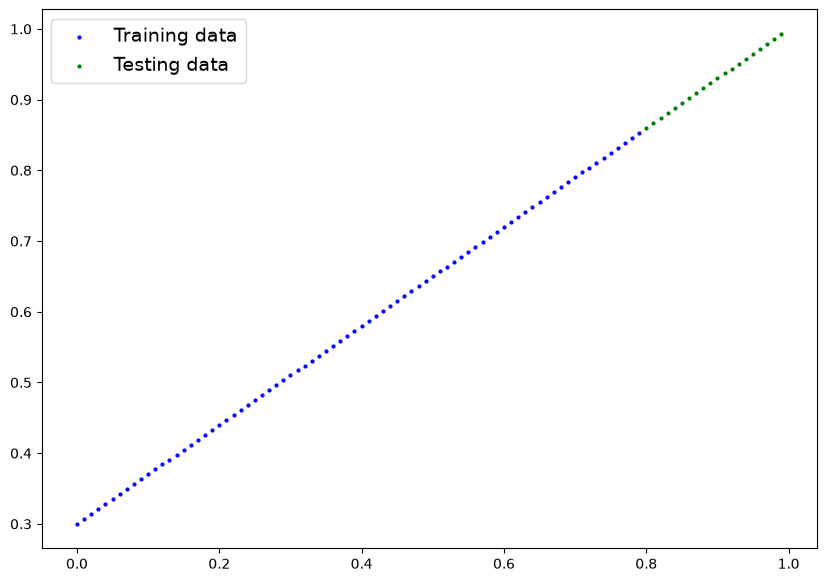

In [58]:
plot_predictions(train_data = X_train_regression,
                 train_labels = y_train_regression,
                 test_data = X_test_regression,
                 test_labels = y_test_regression)

In [59]:
X_train_regression[:10]

tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])

### 5.2 Adjusting `model_2` to fit a straight line

In [60]:
# Same architecture as model_1 (but using nn.Sequential())

model_3 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)   
).to(device)

model_3

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [61]:
loss_fn_3 = nn.L1Loss()
optimizer_3 = torch.optim.SGD(model_3.parameters(),
                              lr = 0.01)

In [62]:
# Train the model
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put the data on the target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    model_3.train()

    y_pred = model_3(X_train_regression)
    loss_3 = loss_fn_3(y_pred, y_train_regression)
    optimizer_3.zero_grad()
    loss_3.backward()
    optimizer_3.step()

    # Testing
    model_3.eval()
    
    with torch.inference_mode():
        test_pred = model_3(X_test_regression)
        test_loss = loss_fn_3(test_pred, y_test_regression)


    # Print out what is happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss_3: .5f} | Test Loss: {test_loss: .5f}")


Epoch: 0 | Loss:  0.75986 | Test Loss:  0.91103
Epoch: 100 | Loss:  0.02858 | Test Loss:  0.00081
Epoch: 200 | Loss:  0.02533 | Test Loss:  0.00209
Epoch: 300 | Loss:  0.02137 | Test Loss:  0.00305
Epoch: 400 | Loss:  0.01964 | Test Loss:  0.00341
Epoch: 500 | Loss:  0.01940 | Test Loss:  0.00387
Epoch: 600 | Loss:  0.01903 | Test Loss:  0.00379
Epoch: 700 | Loss:  0.01878 | Test Loss:  0.00381
Epoch: 800 | Loss:  0.01840 | Test Loss:  0.00329
Epoch: 900 | Loss:  0.01798 | Test Loss:  0.00360


In [63]:
# Turn on evaluation mode
model_3.eval()

# Make prediction (Inference)
with torch.inference_mode():
    y_preds = model_3(X_test_regression)

In [64]:
print(X_train_regression.shape) 
print(y_train_regression.shape)
print(X_test_regression.shape)
print(y_test_regression.shape)
print(y_preds.shape)

torch.Size([80, 1])
torch.Size([80, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([20, 1])


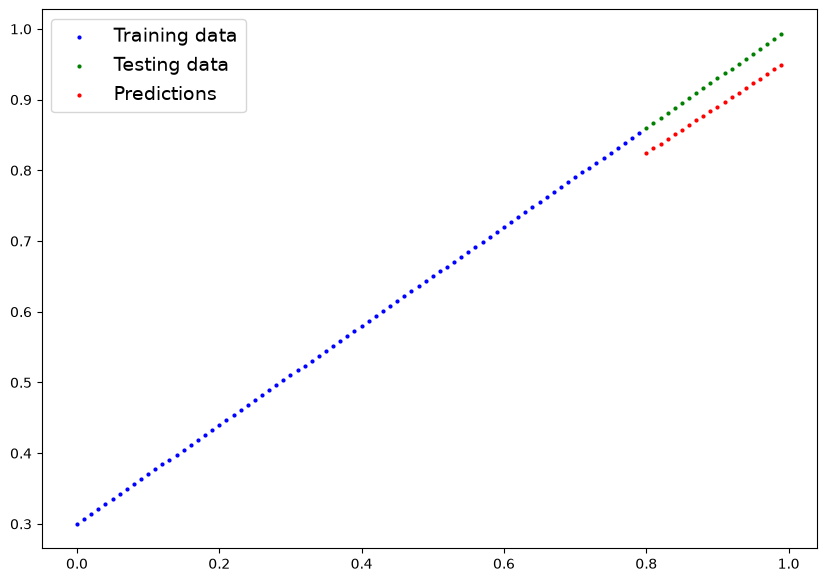

In [65]:
# Plot data and predictions
4
plot_predictions(train_data = X_train_regression.cpu(),
                 train_labels = y_train_regression.cpu(),
                 test_data = X_test_regression.cpu(),
                 test_labels = y_test_regression.cpu(),
                 predictions=y_preds.cpu())

### 6. Missing piece: non-linearity

"What ppaterns could you draw if you were given an infinvite amount off straight and non-straight lines?"

or in ML terms, an infinite (but really is finite) of linear and non-linear functions

### 6.1 Recreating non-linearity data (red and blue circles)

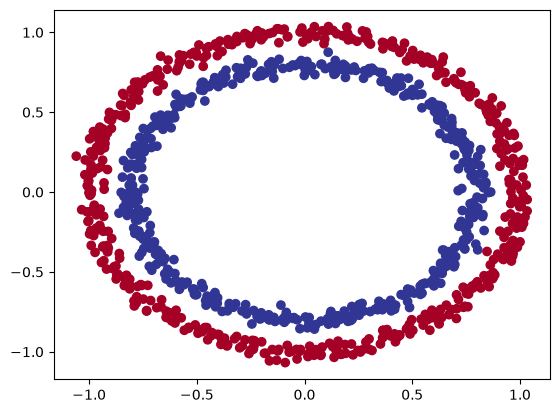

In [66]:
# Make and plot the data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
n_samples = 1000

X, y = make_circles(n_samples,
                    noise= 0.03,
                    random_state = 42)

plt.scatter(X[:, 0], X[:,1], c=y, cmap = plt.cm.RdYlBu)

In [67]:
type(X)

numpy.ndarray

In [68]:
# Convert data into tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split the dataset into training and test
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non-linearity 

* Linear = straight line
* Non-Linear = Not a straight line

Aertificial Neural Networks are a large combination of linear (straight) and non-straight (non-linear_ function) which are potentially able to find patterns in data

In [69]:
# Build a model with non-linear activation function

from torch import nn

class CircleModelV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU()
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Where should we put our non-linear activation functions?
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))


model_4 = CircleModelV3().to(device)
model_4

CircleModelV3(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [70]:
loss_fn_model_4 = nn.BCEWithLogitsLoss() # MAE Loss
optimizer_model_4 = torch.optim.SGD(params=model_4.parameters(),
                                    lr = 0.1)

In [71]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1400

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_4.train()

    #1. Forward Pass

    y_preds_logit = model_4(X_train).squeeze()
    y_preds_model_4 = torch.round(torch.sigmoid(y_preds_logit))

    #2. Calculate the loss
    loss_model_4 = loss_fn_model_4(y_preds_logit, 
                                   y_train) # Loss models takes in logit as input

    acc_model_4 = accuracy_fn(y_true = y_train,
                              y_pred = y_preds_model_4)

    #3. Gradients back to 0
    optimizer_model_4.zero_grad()

    #4. Loss backward
    loss_model_4.backward()

    #5.  Stop the optimizer
    optimizer_model_4.step()

    #6. Evaluate the model by making the predictions
    model_4.eval()

    with torch.inference_mode():
        test_pred_logit = model_4(X_test).squeeze()
        test_pred_model_4 = torch.round(torch.sigmoid(test_pred_logit))

        test_model_4_loss = loss_fn_model_4(test_pred_logit, y_test)
        test_acc = accuracy_fn(y_true = y_test,
                               y_pred = test_pred_model_4)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} Accuracy: {acc_model_4} Train Loss: {loss_model_4} Test Loss: {test_model_4_loss} Test Accuracy: {test_acc}")   

Epoch: 0 Accuracy: 50.0 Train Loss: 0.6929463148117065 Test Loss: 0.6931881308555603 Test Accuracy: 50.0
Epoch: 100 Accuracy: 52.87500000000001 Train Loss: 0.691152811050415 Test Loss: 0.6910240054130554 Test Accuracy: 52.5
Epoch: 200 Accuracy: 53.37499999999999 Train Loss: 0.6897743940353394 Test Loss: 0.6893960237503052 Test Accuracy: 55.00000000000001
Epoch: 300 Accuracy: 53.0 Train Loss: 0.6879494190216064 Test Loss: 0.6872316002845764 Test Accuracy: 56.00000000000001
Epoch: 400 Accuracy: 52.75 Train Loss: 0.6851678490638733 Test Loss: 0.6841148734092712 Test Accuracy: 56.49999999999999
Epoch: 500 Accuracy: 52.75 Train Loss: 0.6810224652290344 Test Loss: 0.6794120669364929 Test Accuracy: 56.49999999999999
Epoch: 600 Accuracy: 54.50000000000001 Train Loss: 0.675148606300354 Test Loss: 0.6728507876396179 Test Accuracy: 56.00000000000001
Epoch: 700 Accuracy: 58.375 Train Loss: 0.6665886044502258 Test Loss: 0.6632164716720581 Test Accuracy: 59.0
Epoch: 800 Accuracy: 64.0 Train Loss: 0.

### 6.4. Evaluating the model trained with non-linear activation functions

In [72]:
# Make predictions

model_4.eval()
with torch.inference_mode():
    y_preds_test = torch.round(torch.sigmoid(model_4(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([[0.8246],
         [0.8312],
         [0.8377],
         [0.8443],
         [0.8509],
         [0.8574],
         [0.8640],
         [0.8706],
         [0.8771],
         [0.8837]], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

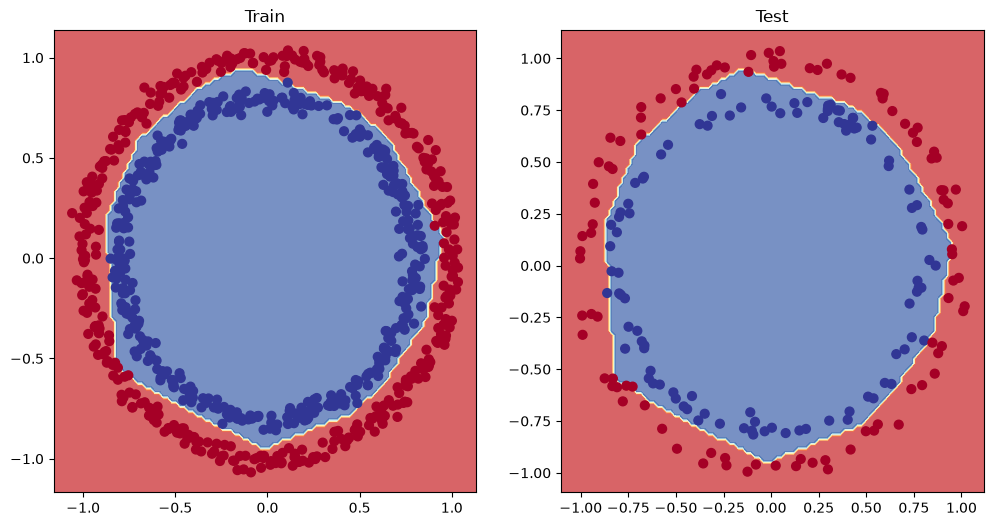

In [73]:
# Plot the decision boundaries
plt.figure(figsize = (12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4,X_test, y_test)

## 7. Replicating non-linear activation functions

Neural networks, rather than telling the model what to learn, we give it the tools to disocver the patterns in data and it tries to figure out the patterns on it's own.

And these tools are linear & non-linear functions

In [74]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype = torch.float32)
A.dtype

torch.float32

In [75]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

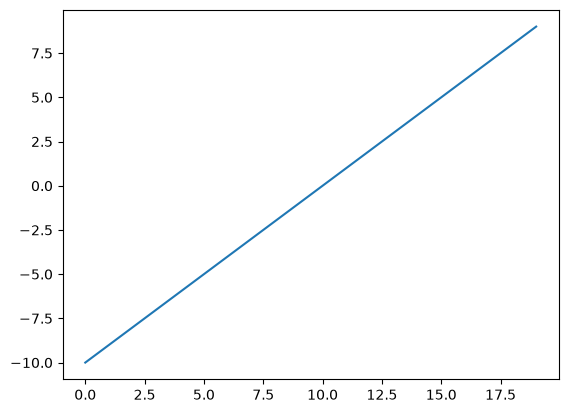

In [76]:
# Visualize the tensor

plt.plot(A)

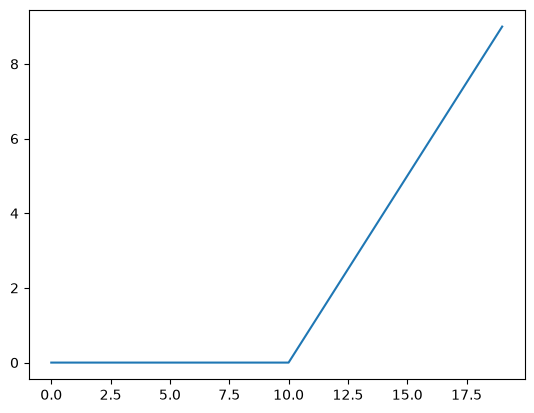

In [77]:
plt.plot(torch.relu(A))

In [78]:
torch.relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

In [79]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x) # inputs must be tensors

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

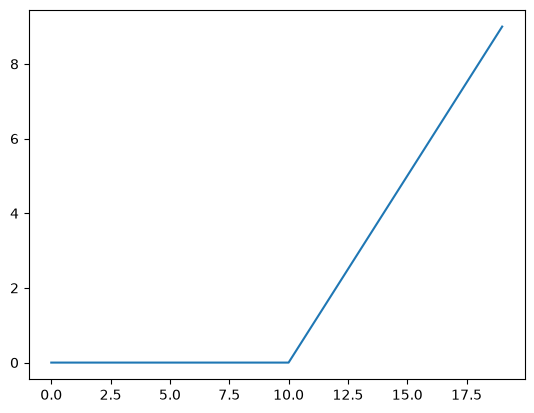

In [80]:
plt.plot(relu(A))

In [81]:
def sigmoid(x: torch.Tensor) -> torch.Tensor:
    return 1 / (1 + torch.exp(-x))

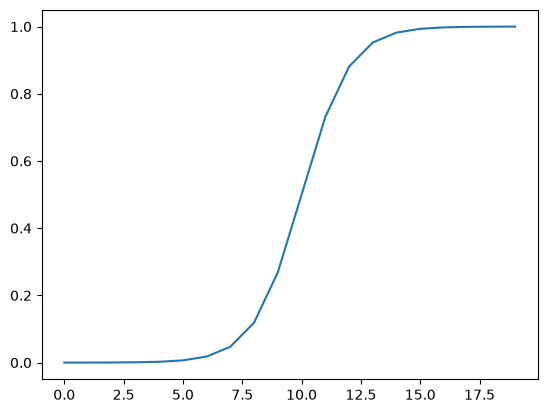

In [82]:
plt.plot(torch.sigmoid(A))

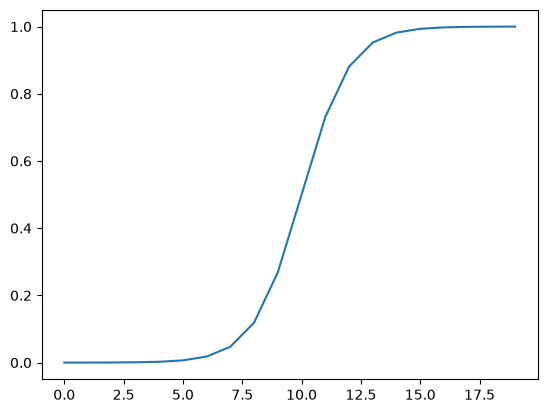

In [83]:
plt.plot(sigmoid(A))

## 8. Putting it all topopgether with a multi-class classification problem

* Binary classification = one thing or another (cat vs dog, spam vs not spam, spam tweet or  not, fraud or not fraud)
* Multi-class classification = more than one thing or another (cat vs dog vs chicken)

### 8.1 Creating a toy multi class dataset

In [84]:
# import dependencies
import torch
import torch.nn as nn
import matplotlib.pyplot
from sklearn.datasets import make_blobs # https://scikit-learn.org/
from sklearn.model_selection import train_test_split

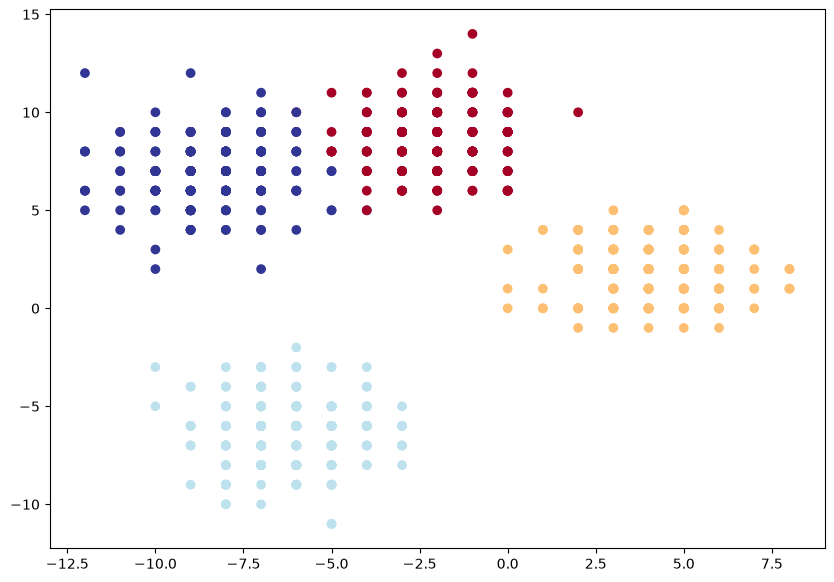

In [ ]:
# Captital because they are hyperparameters

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples= 1000,
                            n_features = NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5, # give the clusters a little shake up
                            random_state = RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.LongTensor)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size = 0.2,
                                                                        random_state = RANDOM_SEED)

# 4. Plot data( visualize, visaluze, vvisualize)
plt.figure(figsize = (10,7))
plt.scatter(X_blob[:, 0], X_blob[:,1], c=y_blob, cmap = plt.cm.RdYlBu)


In [115]:
X_blob_train.dtype, X_blob.dtype

(torch.int64, torch.int64)

### 8.2 Building a multi class classification model

In [106]:
torch.cuda.is_available()

True

In [107]:
# Create deevice agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [108]:
# Build a multi-class classification model

class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units = 8):
        """ Initializes multi-class classification model.
        Args:
        input_features (int): Number of input features to the model
        output_features (int): Number of output features (number of output classes) 
        hidden_units (int): Number of hidden units between layers, default 8

        Returns:

        Example:

        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
        # self.layer_1 = nn.Linear(in_features = NUM_FEATURES, out_features=10)
        # self.layer_2 = nn.Linear(in_features=10, out_features = 10)
        # self.layer_3 = nn.Linear(in_features=10, out_features=1)
        # self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of Blob model and send it to the target device
model_5 = BlobModel(input_features = 2,
                    output_features = 4,
                    hidden_units = 8).to(device)

### 8.3 Create a loss function and an optimizer for a multi-class classification model

In [109]:
# Create a loss function for multi-class classification
loss_fn_model_5 = nn.CrossEntropyLoss()

# Create an optimizer for multi-class classification
optimizer_model_5 = torch.optim.SGD(params = model_5.parameters(),
                                    lr = 0.1) # learning rate is a HYPERparameter you can change

### 8.4 Getting prediction probabilities for a multi-class PyTorch model

In order to evaluate and train and test our model we need to convert our models' output which are logits to prediction probabilities and then to prediction labels.

Logits (raw output of the model)-> Pred probs (use `torch.softmax`) -> Pred labels (take the argmax of the prediction probabilities)

In [119]:
# Let's get some raw output of our model (logits)
model_5.eval()

with torch. inference_mode():
    y_logits_5 = model_5(X_blob_test.to(device))

# y_logits_5[:5]

RuntimeError: mat1 and mat2 must have the same dtype, but got Long and Float

In [ ]:
y_pred_probs = torch.softmax(y_logits_5, dim = 1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.4040],
        [-0.2956],
        [-0.5927],
        [-0.3509],
        [-0.4413]], device='cuda:0')
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]], device='cuda:0')


In [ ]:
torch.sum(y_pred_probs[0])

tensor(1., device='cuda:0')

In [ ]:
torch.max(y_pred_probs[0])

tensor(0.3244, device='cuda:0')

In [ ]:
torch.argmax(y_pred_probs[0])

tensor(1, device='cuda:0')

In [ ]:
# Convert our model's prediction into probabilties to a prediction labels

y_preds = torch.argmax(y_pred_probs,dim = 1)
y_preds


tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1], device='cuda:0')

In [ ]:
y_blob_test

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0., 0., 1., 0., 0., 0., 3., 3., 2.,
        3., 3., 3., 0., 1., 2., 2., 2., 3., 0., 1., 0., 3., 1., 1., 3., 1., 2.,
        1., 3., 0., 2., 0., 3., 3., 2., 0., 3., 1., 1., 0., 3., 1., 0., 1., 1.,
        3., 2., 1., 1., 3., 2., 2., 0., 3., 2., 2., 0., 0., 3., 3., 0., 0., 3.,
        3., 3., 2., 3., 3., 3., 3., 1., 0., 2., 3., 2., 3., 3., 2., 3., 3., 2.,
        3., 3., 1., 3., 3., 3., 1., 0., 3., 2., 0., 0., 3., 0., 2., 3., 1., 0.,
        3., 2., 1., 1., 0., 2., 2., 3., 0., 0., 1., 2., 2., 3., 0., 1., 2., 0.,
        0., 0., 2., 3., 1., 2., 3., 2., 0., 3., 0., 0., 1., 1., 1., 0., 2., 2.,
        2., 2., 0., 3., 3., 2., 2., 1., 3., 2., 0., 0., 3., 3., 2., 1., 2., 0.,
        3., 2., 0., 3., 2., 0., 2., 2., 2., 0., 3., 1., 1., 1., 1., 1., 3., 1.,
        0., 2., 2., 1., 2., 2., 0., 1., 2., 2., 0., 0., 1., 3., 2., 0., 3., 1.,
        2., 1.])

### 8.5 Creating a training loop and testing loop for a multi-class PyTorch model

torch.Tensor

In [ ]:
# Fit the multi-class model tot he data

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
epochs = 100

# Put the data into target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    model_5.train()

    train_logits_pred = model_5(X_blob_train)
    y_pred_train = torch.softmax(train_logits_pred, dim = 1).argmax(dim = 1)

    loss = loss_fn_model_5(train_logits_pred, y_blob_train)
    acc = accuracy_fn(y_true = y_blob_train,
                      y_pred = y_pred_train)

    optimizer_model_5.zero_grad()
    loss.backward()
    optimizer_model_5.step()

    ## Testing
    model_5.eval()

    with torch.inference_mode():
        test_logits = model_5(X_blob_test)
        test_preds = torch.softmax(test_logits, dim = 1).argmax(dim = 1)

        test_loss = loss_fn_model_5(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true = y_blob_test,
                               y_pred = test_preds)

        # Print out what's happening

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {loss: .4f}, | Acc: {acc: .4f} Test Loss: {test_loss}, | Test acc: {test_acc: .4f}")


RuntimeError: expected target dtype to be Long or Byte, but got Float